# **Project Name**    - Flipkart Project



##### **Project Type** - EDA/Classification
##### **Contribution** - Individual
##### **Team Member 1 -** Biplab Mondal

# Project Summary 

This project aims to develop a predictive machine learning model capable of estimating Customer Satisfaction (CSAT) scores based on historical customer support data. Accurate CSAT prediction enables proactive intervention, enhances customer retention, and facilitates data-driven improvements to support operations.

The project begins with comprehensive data preprocessing. This involves handling missing values using median and mode imputation, removing irrelevant columns, and converting date fields. Categorical variables are transformed using one-hot encoding, while all numeric variables are standardised. To address severe class imbalance in CSAT, SMOTE is applied to oversample minority classes within the training set.

Next, multiple classification models are trained and evaluated using metrics such as accuracy, precision, recall, and F1 score. This project delivers actionable insights and recommendations for enhancing service quality, training agents, optimising shift schedules, and prioritising high-friction customer issues. Ultimately, it establishes a foundation for integrating real-time CSAT prediction into customer support systems, enabling continuous performance monitoring and proactive decision-making.

# **Problem Statement**


Flipkart’s customer support team handles numerous daily interactions, addressing issues such as product queries, order problems, returns, and cancellations. However, understanding the factors that drive customer satisfaction remains a challenge. This project analyses customer support data to identify the key factors influencing Customer Satisfaction (CSAT) Scores and develop predictive models that accurately classify CSAT scores. By providing actionable insights, this project aims to improve customer service strategies and enhance the overall customer experience.

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Dataset Loading

In [3]:
# Load Dataset

data = pd.read_csv('/Users/biplab/Downloads/Flipkart Project/Customer_support_data.csv')

### Dataset First View

In [4]:
# Dataset First Look

data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

data.shape

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 85907
Columns: 20


### Dataset Information

In [6]:
# Dataset Info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count

print("Number of duplicates : ", data.duplicated().sum())


Number of duplicates :  0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count

print(data.isnull().sum())
Total_Null_Values = data.isnull().sum().sum()
print("Total Null Values:",Total_Null_Values)

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64
Total Null Values: 435995


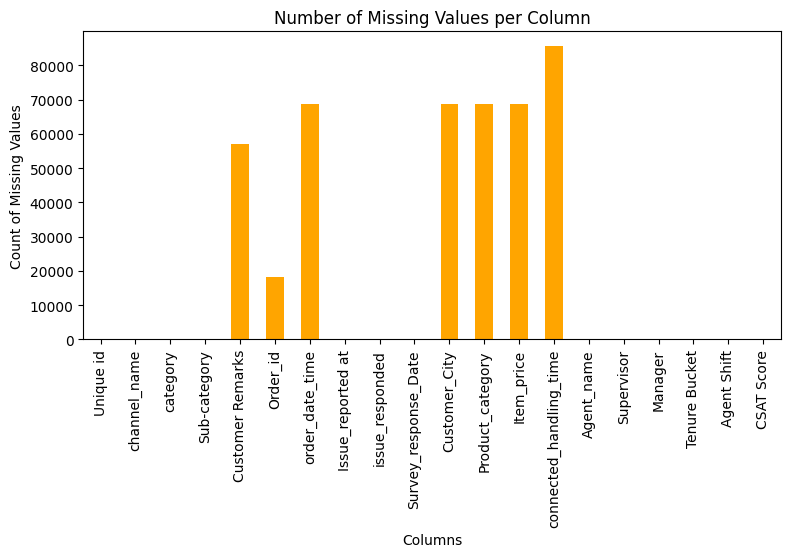

In [9]:
# Visualizing the missing values

data.isnull().sum().plot(kind='bar', figsize=(9,4), color='orange')
plt.title("Number of Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.show()

### What did you know about your dataset?

The dataset, containing 85,907 records and 20 columns, captures various aspects of customer support interactions. It includes categorical variables like communication channel, query category, sub-category, agent details, and managerial information. The primary target variable, Customer Satisfaction Score (CSAT), measures customer satisfaction on a scale of 1 to 5. The dataset also includes customer remarks, Order ID, product details, and handling time. This comprehensive dataset provides valuable insights for analysing customer satisfaction patterns, assessing agent performance, and evaluating service efficiency.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns

data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [11]:
# Dataset Describe

data.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

Unique id : Unique identifier for each record

Channel name : Name of the customer service channel

Category : Category of the interaction

Sub-category : Sub-category of the interaction

Customer Remarks : Feedback provided by the customer

Order id : Identifier for the order associated with the interaction

Order date time : Date and time of the order

Issue reported at : Timestamp when the issue was reported

Issue responded : Timestamp when the issue was responded to

Survey response date : Date of the customer survey response

Customer city : City of the customer

Product category : Category of the product

Item price : Price of the item

Connected handling time : Time taken to handle the interaction

Agent name : Name of the customer service agent

Supervisor : Name of the supervisor

Manager : Name of the manager

Tenure Bucket : Bucket categorizing agent tenure

Agent Shift : Shift timing of the agent

CSAT Score : Customer Satisfaction (CSAT) score

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

data.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

In [13]:
# Convert specific date and time columns to its specific pandas datetime format

data['order_date_time'] = pd.to_datetime(data['order_date_time'], errors='coerce')
data['Issue_reported at'] = pd.to_datetime(data['Issue_reported at'], errors='coerce')
data['issue_responded']   = pd.to_datetime(data['issue_responded'], errors='coerce')

# Convert to only date format as its only having date 
data['Survey_response_Date'] = pd.to_datetime(data['Survey_response_Date'], errors='coerce').dt.date


In [14]:
# Let's check the datatype again after datetime conversion

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Unique id                85907 non-null  object        
 1   channel_name             85907 non-null  object        
 2   category                 85907 non-null  object        
 3   Sub-category             85907 non-null  object        
 4   Customer Remarks         28742 non-null  object        
 5   Order_id                 67675 non-null  object        
 6   order_date_time          17214 non-null  datetime64[ns]
 7   Issue_reported at        31974 non-null  datetime64[ns]
 8   issue_responded          31885 non-null  datetime64[ns]
 9   Survey_response_Date     85907 non-null  object        
 10  Customer_City            17079 non-null  object        
 11  Product_category         17196 non-null  object        
 12  Item_price               17206 n

In [15]:
data.head(15)

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
5,1cfde5b9-6112-44fc-8f3b-892196137a62,Email,Returns,Fraudulent User,NaN,a2938961-2833-45f1-83d6-678d9555c603,NaT,2023-01-08 15:13:00,2023-01-08 18:39:00,2023-08-01,NaN,NaN,NaN,NaN,Desiree Newton,Emma Park,John Smith,0-30,Morning,5
6,11a3ffd8-1d6b-4806-b198-c60b5934c9bc,Outcall,Product Queries,Product Specific Information,NaN,bfcb562b-9a2f-4cca-aa79-fd4e2952f901,NaT,2023-01-08 15:31:00,2023-01-08 23:52:00,2023-08-01,NaN,NaN,NaN,NaN,Shannon Hicks,Aiden Patel,Olivia Tan,>90,Morning,5
7,372b51a5-fa19-4a31-a4b8-a21de117d75e,Inbound,Returns,Exchange / Replacement,Very good,88537e0b-5ffa-43f9-bbe2-fe57a0f4e4ae,NaT,2023-01-08 16:17:00,2023-01-08 16:23:00,2023-08-01,NaN,NaN,NaN,NaN,Laura Smith,Evelyn Kimura,Jennifer Nguyen,On Job Training,Evening,5
8,6e4413db-4e16-42fc-ac92-2f402e3df03c,Inbound,Returns,Missing,Shopzilla app and it's all coustomer care serv...,e6be9713-13c3-493c-8a91-2137cbbfa7e6,NaT,2023-01-08 21:03:00,2023-01-08 21:07:00,2023-08-01,NaN,NaN,NaN,NaN,David Smith,Nathan Patel,John Smith,>90,Split,5
9,b0a65350-64a5-4603-8b9a-a24a4a145d08,Inbound,Shopzilla Related,General Enquiry,NaN,c7caa804-2525-499e-b202-4c781cb68974,NaT,2023-01-08 23:31:00,2023-01-08 23:36:00,2023-08-01,NaN,NaN,NaN,NaN,Tabitha Ayala,Amelia Tanaka,Michael Lee,31-60,Evening,5


## 3. ***Data Wrangling***

### Data Wrangling Code

Data Wrangling like missing values imputation, outlier treatments will be process in coming steps.

### What all manipulations have you done and insights you found?

Dropped columns which have more than 80% of missing values. Categorical columns with ‘mode’ to explicitly indicate missing data as the most frequent value will count, and numeric columns with the median to represent typical values without being affected by outliers. Datetime columns remain NaT as missing dates cannot be reliably inferred. Also, I have done One-Hot encoding for categorical varibales to convert them into numeric dummy varibales. 

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Part 1 - Univariate Analysis

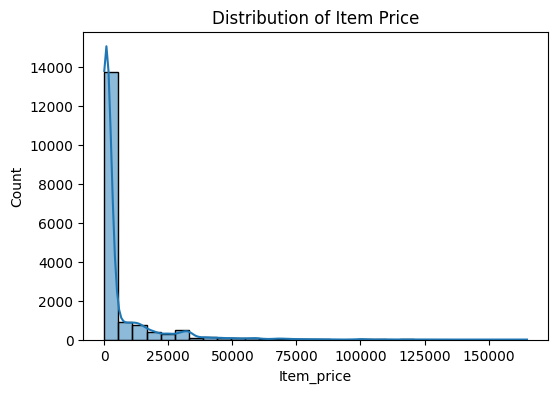

In [17]:
# Chart - 1 Histogram of Numerical Variable (Item_Price)

plt.figure(figsize=(6,4))
sns.histplot(data['Item_price'], bins=30, kde=True)
plt.title("Distribution of Item Price")
plt.show()

##### 1. Why did you pick the specific chart?

Most of the product purchased by customers price under 14000.

##### 2. What is/are the insight(s) found from the chart?

Should focus product under 14000 price category and how it will increase in future.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, Business team should focus on particular product category improvisations.

#### Chart - 2

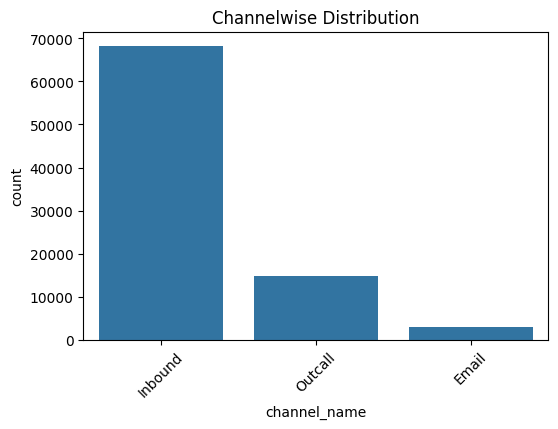

In [18]:
# Chart - 2 Countplot of categorical variable (channel_name)

plt.figure(figsize=(6,4))
sns.countplot(x='channel_name', data=data, order=data['channel_name'].value_counts().index)
plt.title("Channelwise Distribution")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Most of the customers called directly to customer care compared to mail and outcall.

##### 2. What is/are the insight(s) found from the chart?

Agent team, their supervisors, and managers should more focus on Inbound call compare to others. 

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

More imbound calls due to customers are facing problem after their product purchase. So, Business team should analysis more for their improvement.

#### Chart - 3

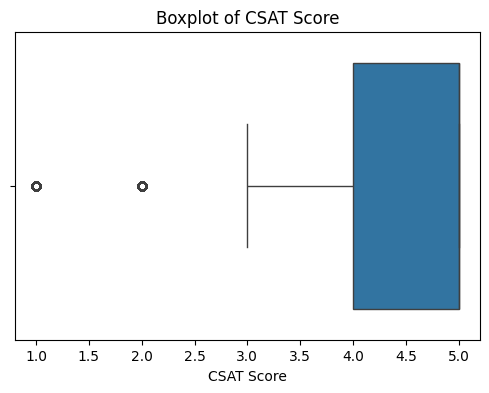

In [19]:
# Chart - 3 Boxplot of CSAT Score

plt.figure(figsize=(6,4))
sns.boxplot(x=data['CSAT Score'])
plt.title("Boxplot of CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

High CSAT score, means customers are happy after their interaction with agents.

##### 2. What is/are the insight(s) found from the chart?

Agent team need to keep the same work continuing, so that feedback will be better.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, It shows positive business impact due to good feedback and overall good CSAT score.

#### Part 2 - Bivariate Analysis

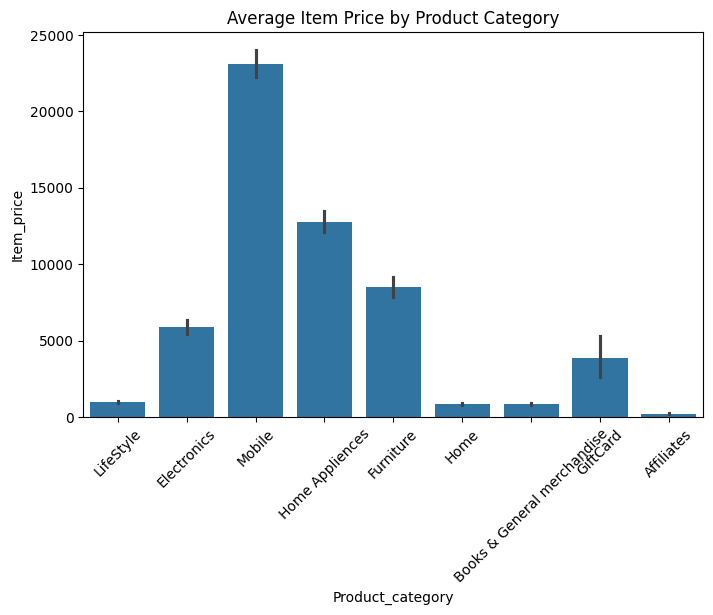

In [20]:
# Chart - 4 Barplot for Avg Item Price by Product Category

plt.figure(figsize=(8,5))
sns.barplot(x='Product_category', y='Item_price', data=data, estimator='mean')
plt.title("Average Item Price by Product Category")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To understand the top product categories.

##### 2. What is/are the insight(s) found from the chart?

Mobile, Home Appliences, Furniture, and Electronics are the top category products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, Team should focus on these category products more and their interation with customers.

#### Chart - 5

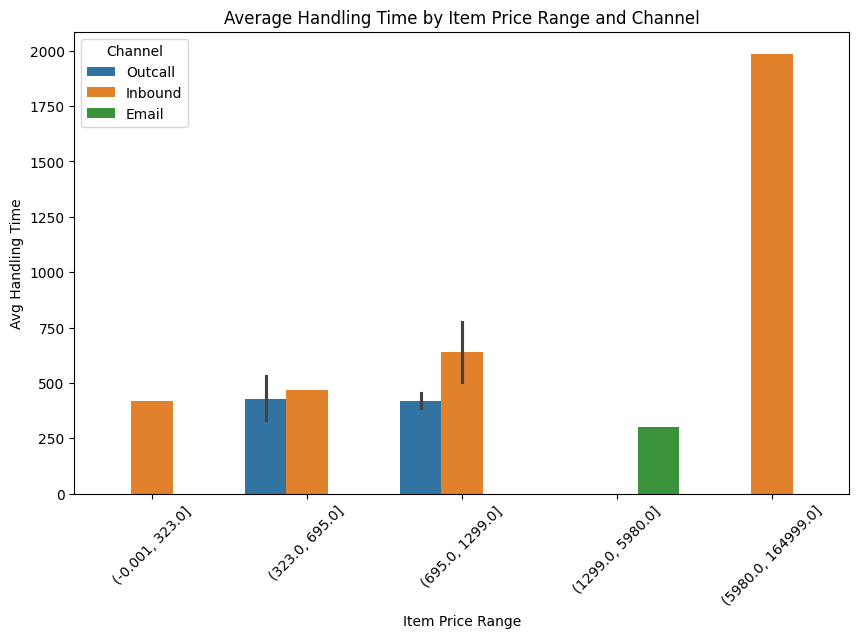

In [21]:
# Chart - 5 Item Price vs Channel Handling time

# Bin Item_price into ranges (5 quantile bins)
data['price_bin'] = pd.qcut(data['Item_price'], q=5, duplicates='drop')  

plt.figure(figsize=(10,6))
sns.barplot(x='price_bin', y='connected_handling_time', hue='channel_name', data=data, estimator='mean')
plt.title("Average Handling Time by Item Price Range and Channel")
plt.xlabel("Item Price Range")
plt.ylabel("Avg Handling Time")
plt.xticks(rotation=45)
plt.legend(title="Channel")
plt.show()

##### 1. Why did you pick the specific chart?

How much time it takes to solve customers' query.

##### 2. What is/are the insight(s) found from the chart?

Mostly inbound calls are taking more time compared to email and outbound. Higher the items price range tells that they have more query to deliver their problems and agent understanding.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Inbound team should more focus on customoers who purchased higher price range items.

#### Chart - 6

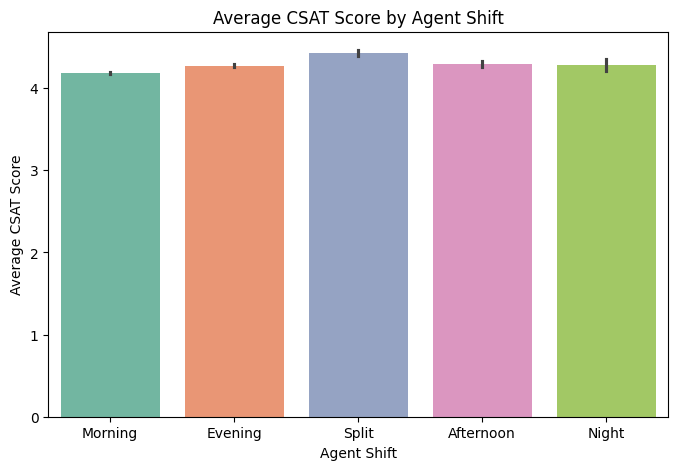

In [22]:
# Chart - 6 Avg CSAT score per shift

plt.figure(figsize=(8,5))
sns.barplot(x='Agent Shift', y='CSAT Score', data=data, estimator='mean', palette="Set2")
plt.title("Average CSAT Score by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Average CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

To understand CSAT score in each agent shift timings.

##### 2. What is/are the insight(s) found from the chart?

All shift agents are having similar CSAT score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Nothing much, Agent need to keep the same work continuing. 

#### Multivariate Analysis

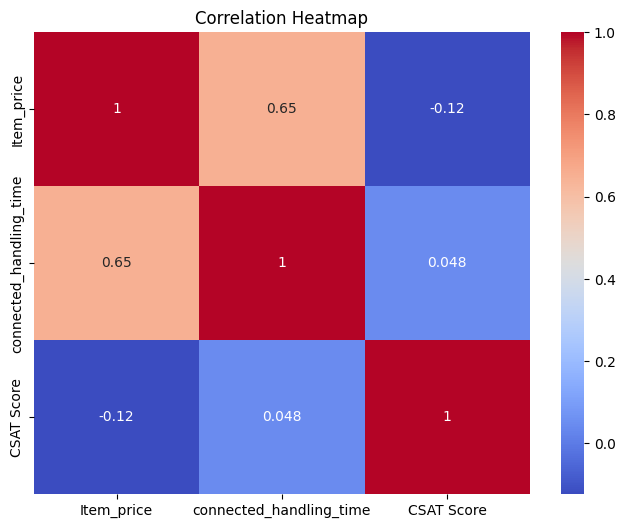

In [23]:
# Chart - 7 Heatmap for Correlation of Numeric Variables

plt.figure(figsize=(8,6))
sns.heatmap(data[['Item_price','connected_handling_time','CSAT Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Chart - 8

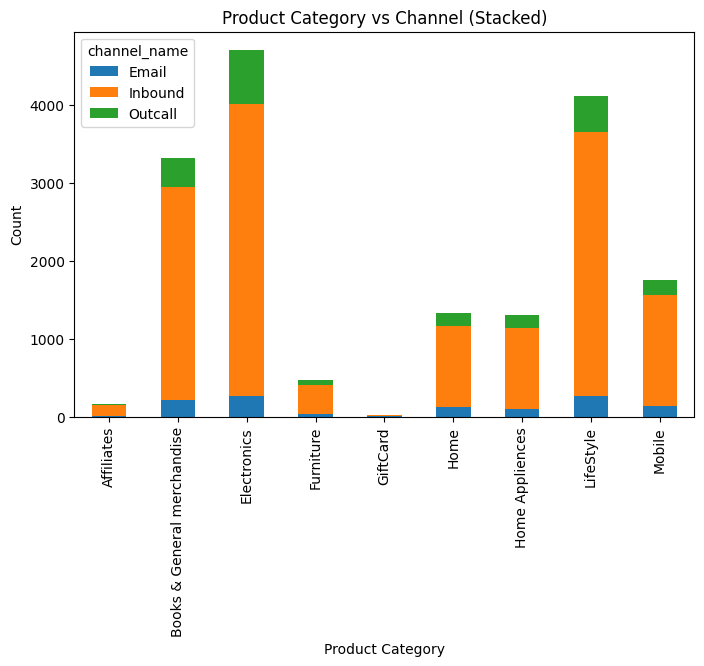

In [24]:
# Chart - 8 Stacked Bar : Product Category vs Channel (count of orders)

cross_tab = pd.crosstab(data['Product_category'], data['channel_name'])
cross_tab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Product Category vs Channel (Stacked)")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

To understand the product category with their count of orders and communication medium for customer query.

##### 2. What is/are the insight(s) found from the chart?

Books, Electronics, Lifestyle, and Mobile category customers are having more imbound calls compared to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Team should focus more on these particular category customers with imbound dependencies.

#### Chart - 9

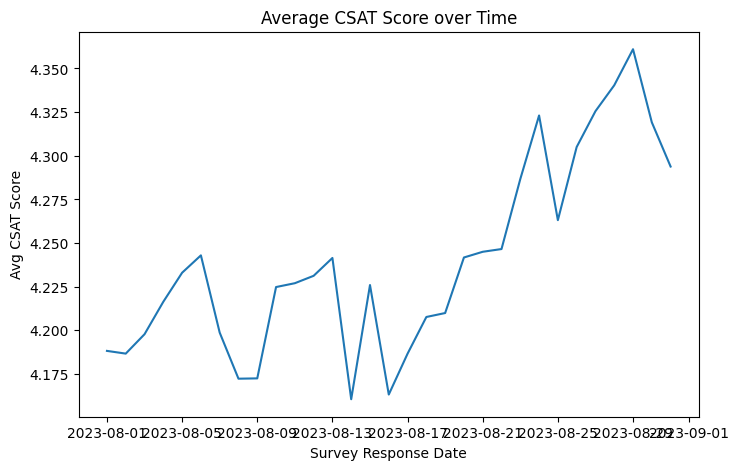

In [25]:
# Chart - 9 Lineplot: Average CSAT Score over Survey Response Date

plt.figure(figsize=(8,5))
data.groupby('Survey_response_Date')['CSAT Score'].mean().plot(kind='line')
plt.title("Average CSAT Score over Time")
plt.xlabel("Survey Response Date")
plt.ylabel("Avg CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

Need to understand how CSAT getting improve.

##### 2. What is/are the insight(s) found from the chart?

Average CSAT over time is increasing and its a good sign of good work.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Customer support team should keep their good work for better CSAT score in upcoming days.

In [26]:
# Drop price_bin as it was created for visualisation

data.drop(['price_bin'], axis=1, inplace=True)

### Hypothesis Testing

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): The average handling time is the same for E-Mail and Call channels.
Alternate Hypothesis (H1): The average handling time is different between E-Mail and Call channels.


#### 2. Perform an appropriate statistical test.

In [27]:
# # Channel vs Handling Time (t-test)

# from scipy.stats import ttest_ind

# # Separate handling times by channel
# email_time= data.loc[data['channel_name']=='Email', 'connected_handling_time']
# call_time= data.loc[data['channel_name']=='Call', 'connected_handling_time']

# # Independent t-test
# t_stat, p_value = ttest_ind(email_time, call_time, equal_var=False)
# print("T-statistic:", t_stat)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print("Conclusion: Reject H0 → Handling time differs between Email and Call")
# else:
#     print("Conclusion: Fail to reject H0 → No significant difference")


##### Which statistical test have you done to obtain P-Value?

Performed an Independent two-sample t-test to compare the means of two independent groups.


##### Why did you choose the specific statistical test?

Since handling time is numerical and channel_name has two independent categories (Email vs Call), an independent t-test is suitable to determine if their means differ.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

The null hypothesis (H0) states that the average CSAT score is the same for Day Shift and Night Shift agents, while the alternate hypothesis (H1) suggests it’s different.


#### 2. Perform an appropriate statistical test.

In [28]:
# # Agent Shift vs CSAT Score (t-test)

# day_shift = data.loc[data['Agent Shift']=='Day', 'CSAT Score']
# night_shift = data.loc[data['Agent Shift']=='Night', 'CSAT Score']

# # Independent t-test
# t_stat, p_value = ttest_ind(day_shift, night_shift, equal_var=False)
# print("T-statistic:", t_stat)
# print("P-value:", p_value)

# if p_value < 0.05:
#     print("Conclusion: Reject H0 → CSAT differs between Day and Night shift")
# else:
#     print("Conclusion: Fail to reject H0 → No significant difference")


##### Which statistical test have you done to obtain P-Value?

Conducted a Welch’s t-test to compare the means of CSAT Scores between two independent agent shifts.

##### Why did you choose the specific statistical test?

Since CSAT Score is numeric and Agent Shift has two independent categories (Day vs Night), an independent t-test is suitable to determine if their means differ.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [29]:
# Missing value imputation

# Drop columns with more than 20% missing values
data = data.dropna(thresh=len(data) * 0.8, axis=1)

# Fill missing values in categorical columns with mode (most frequent value)
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Fill missing values in numeric columns with median
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col] = data[col].fillna(data[col].median())


#### What all missing value imputation techniques have you used and why did you use those techniques?

Columns with an excessive number of missing values were removed. Dropped columns which have more than 80% of missing values.

For categorical variables, mode imputation was employed. The mode represents the most frequent category and effectively fills missing values while preserving prevalent trends within the dataset.

For numerical variables, median imputation was utilised. The median is resilient to outliers and mitigates skewing of the data, making it a suitable choice for numerical columns with missing values.

### 2. Handling Outliers

In [30]:
data.head()

,Unique id,channel_name,category,Sub-category,Survey_response_Date,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,2023-08-01,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,2023-08-01,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,2023-08-01,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,2023-08-01,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,2023-08-01,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


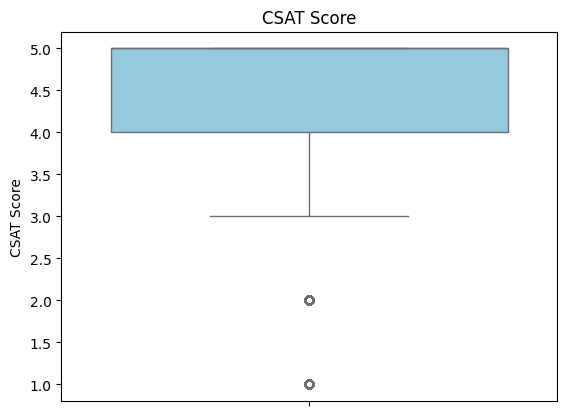

In [31]:
# Handling Outliers

for col in data.select_dtypes(include=['number']):
    sns.boxplot(data[col], color='skyblue')
    plt.title(col)
    plt.show()
    
    data[col].fillna(data[col].median(), inplace=True)

In [32]:
# Outlier treatments using IQR (capping)

Q1, Q3 = data[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
data[col] = np.where(data[col] < lower, lower,
              np.where(data[col] > upper, upper, data[col]))

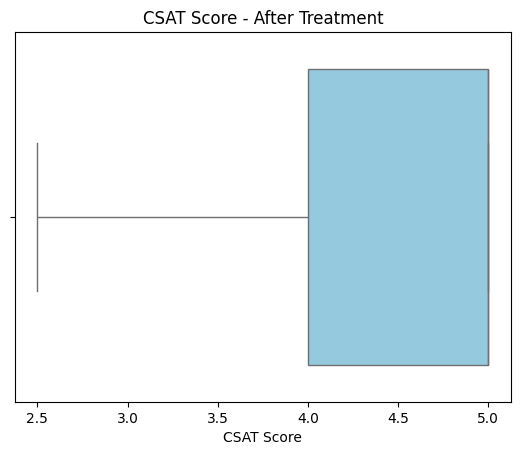

In [33]:
# After outlier treatment 

# Boxplot after treatment
sns.boxplot(x=data[col], color='skyblue')
plt.title(f"{col} - After Treatment")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Used Boxplot method (IQR method) to detect outliers and also IQR-based capping is used to handle outliers by limiting extreme values without removing data, preserving dataset size and reducing their influence on analysis.



### 3. Categorical Encoding

In [34]:
# Encode your categorical columns

# Select relevant columns for modeling
data_model = data[['channel_name', 'category', 'Sub-category', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']].copy()

# One-Hot Encode categorical variables
data_encoded = pd.get_dummies(data_model.drop('CSAT Score', axis=1), drop_first=True)

# Add target variable back
data_encoded['CSAT Score'] = data_model['CSAT Score']

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used for ordinal columns to maintain order, while One-Hot Encoding was used for nominal columns to convert categories into numeric values without implying order, preparing the data for analysis and machine learning.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [35]:
# Check correlation among numeric features 

# Step 1: Select categorical columns to encode
categorical_cols = ['channel_name', 'category', 'Sub-category', 'Agent Shift', 'Tenure Bucket']

# Step 2: Apply one-hot encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Step 3: Check result
print("Encoded DataFrame shape:", data_encoded.shape)
print("Encoded columns:\n", data_encoded.columns.tolist())


Encoded DataFrame shape: (85907, 83)
Encoded columns:
 ['Unique id', 'Survey_response_Date', 'Agent_name', 'Supervisor', 'Manager', 'CSAT Score', 'channel_name_Inbound', 'channel_name_Outcall', 'category_Cancellation', 'category_Feedback', 'category_Offers & Cashback', 'category_Onboarding related', 'category_Order Related', 'category_Others', 'category_Payments related', 'category_Product Queries', 'category_Refund Related', 'category_Returns', 'category_Shopzilla Related', 'Sub-category_Affiliate Offers', 'Sub-category_App/website Related', 'Sub-category_Billing Related', 'Sub-category_COD Refund Details', 'Sub-category_Call back request', 'Sub-category_Call disconnected', 'Sub-category_Card/EMI', 'Sub-category_Commission related', 'Sub-category_Customer Requested Modifications', 'Sub-category_Damaged', 'Sub-category_Delayed', 'Sub-category_Exchange / Replacement', 'Sub-category_Fraudulent User', 'Sub-category_General Enquiry', 'Sub-category_Installation/demo', 'Sub-category_Instant 

#### 2. Feature Selection

Top Feature Importances:
 Sub-category_Return request      0.102251
channel_name_Inbound             0.057161
channel_name_Outcall             0.056453
Sub-category_Fraudulent User     0.056281
Tenure Bucket_>90                0.046636
Sub-category_Missing             0.042002
Agent Shift_Morning              0.038190
Agent Shift_Evening              0.036978
Tenure Bucket_On Job Training    0.034585
Tenure Bucket_31-60              0.034369
dtype: float64


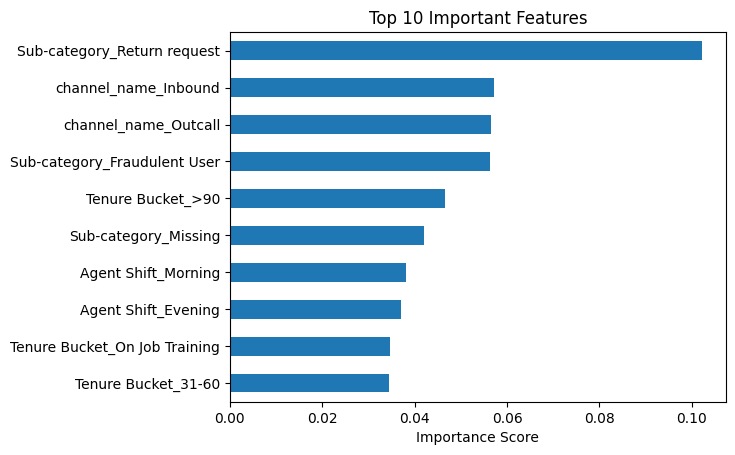

In [36]:
# Step 1: Select relevant columns
selected_features = ['channel_name', 'category', 'Sub-category', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']
data_model = data[selected_features].copy()

# Step 2: One-hot encode categorical features
data_encoded = pd.get_dummies(data_model, drop_first=True)

# Step 3: Split into features and target
X = data_encoded.drop(columns=['CSAT Score'])
y = data_encoded['CSAT Score']

# Step 4: Train Random Forest
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Step 5: Display feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Feature Importances:\n", importances.head(10))

# Plot
importances.head(10).plot(kind='barh', title='Top 10 Important Features')
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

##### What all feature selection methods have you used  and why?

Used one-hot encoding to turn categorical features into numbers, and Random Forest feature importance analysis to figure out which features are the most important in predicting CSAT scores. This way, we’re sure that all the inputs are good for training the model and we can easily identify the most important predictors for further analysis.


##### Which all features you found important and why?

The most important features were Sub-category_Return request, channel_name_Inbound/Outcall, Sub-category_Fraudulent User, Tenure Bucket_>90, and Agent Shift_Morning/Evening, as they most strongly impact CSAT Score by reflecting key customer interactions and issue types that drive satisfaction.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Data transformation was necessary for this analysis to prepare the dataset for machine learning modelling. The dataset had several categorical variables, so I applied one-hot encoding to convert them into numerical format. This was essential because machine learning algorithms like Random Forest require numeric input and can’t process textual or categorical data directly. One-hot encoding ensured the model could interpret each category distinctly without assuming an ordinal relationship. Scaling or normalisation wasn’t applied because Random Forest is a tree-based model and unaffected by data scale.

### 6. Data Scaling

In [37]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

# Numeric columns except target
num_cols = [c for c in data_encoded.select_dtypes('number') if c != 'CSAT Score']

if num_cols:
    data_encoded[num_cols] = StandardScaler().fit_transform(data_encoded[num_cols])
    print("Scaled:", num_cols)
else:
    print("No numeric columns to scale.")

No numeric columns to scale.


##### Which method have you used to scale you data and why?

The data was scaled using StandardScaler from scikit-learn. This standardises numeric features by removing their mean and scaling them to unit variance, ensuring all variables have the same scale and preventing features with larger ranges from dominating the model.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction isn’t crucial for this dataset now. After feature selection and encoding, the number of features is small and manageable, so overfitting from high dimensionality is unlikely. Models like Random Forest and XGBoost handle high-dimensional data well and aren’t sensitive to feature count.

### 8. Data Splitting

In [38]:
# Split the dataset to train and test as 80-20 ratio

from sklearn.model_selection import train_test_split

X, y = data_encoded.drop("CSAT Score", axis=1), data_encoded["CSAT Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##### What data splitting ratio have you used and why?

I used an 80:20 train-test split ratio, where 80% of the data was used for training and 20% was used for testing. This ratio ensures a balanced approach to training and evaluation, allowing the model to learn effectively from a large portion of the data while maintaining an unbiased assessment of its performance.


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes the dataset is imbalanced. The CSAT Score data is highly imbalanced, with near 70% of responses being 5 and minority scores (1–4) underrepresented. This imbalance can bias models toward the majority class, yielding high overall accuracy but poor prediction for minority scores. Consequently, precision and recall are low for CSAT scores 1–4.

In [45]:
# Handling Imbalanced Dataset 

# Handling Imbalanced Dataset (Updated for float CSAT)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Convert all boolean/numeric columns to integers (0/1) for X
X = data_encoded.drop("CSAT Score", axis=1).copy()
X = X.astype(int)

# Convert CSAT Score to discrete integer classes
y = data_encoded["CSAT Score"].round().astype(int)

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 3: Class balance check
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())


Before SMOTE:
 CSAT Score
5    47693
2    10010
4     8975
3     2047
Name: count, dtype: int64

After SMOTE:
 CSAT Score
5    47693
2    47693
4    47693
3    47693
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Our target variable, CSAT Score, was heavily skewed toward class 5, while classes 2, 3, and 4 were underrepresented.

SMOTE creates synthetic samples for the minority classes by interpolating between existing samples, rather than simply duplicating them.

This balances all classes in the training set, helping our model learn equally from all CSAT scores and improving its ability to predict minority classes accurately.

## ***7. ML Model Implementation***

### ML Model - 1

In [46]:
# ML Model - 1 RandomForestClassifier

# Fit the Algorithm
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("\nRandom Forest Classifier (with SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))
     


Random Forest Classifier (with SMOTE):
Accuracy: 0.6921778605517402

Classification Report:
               precision    recall  f1-score   support

           2       0.38      0.02      0.04      2503
           3       0.00      0.00      0.00       511
           4       0.12      0.00      0.00      2244
           5       0.70      0.99      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.30      0.25      0.21     17182
weighted avg       0.55      0.69      0.57     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

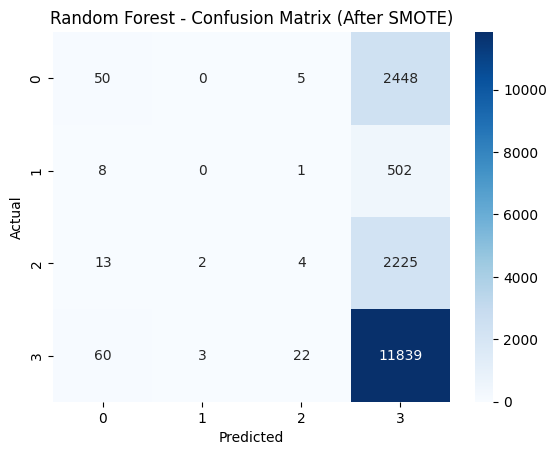

In [47]:
# Visualizing evaluation Metric Score chart

conf_mat = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix (After SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [48]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Hyperparameter Tuning using GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


#  Fit the Algorithm

grid_search.fit(X_train, y_train)

# Best parameters found
print("Best Parameters Found:", grid_search.best_params_)


#  Predict on the Model

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)


#  Evaluation

print("\nRandom Forest Classifier with GridSearchCV (No SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))


Fitting 3 folds for each of 48 candidates, totalling 144 fits


/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas re

Best Parameters Found: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}

✅ Random Forest Classifier with GridSearchCV (No SMOTE):
Accuracy: 0.6939820742637645

Classification Report:
               precision    recall  f1-score   support

           2       0.00      0.00      0.00      2503
           3       0.00      0.00      0.00       511
           4       0.00      0.00      0.00      2244
           5       0.69      1.00      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.17      0.25      0.20     17182
weighted avg       0.48      0.69      0.57     17182



##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV to tune the Random Forest Classifier. It exhaustively searches a manually specified subset of hyperparameters and evaluates each combination using cross-validation. This technique is straightforward, reliable, and suitable for moderate-sized datasets like this project.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, After GridSearchCV tuning the accuracy score slightly improved from 0.692 to 0.693.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


 Logistic Regression (Default Parameters):
Accuracy: 0.6940984751484112

Classification Report:
               precision    recall  f1-score   support

           2       0.44      0.00      0.01      2503
           3       0.00      0.00      0.00       511
           4       0.00      0.00      0.00      2244
           5       0.69      1.00      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.28      0.25      0.21     17182
weighted avg       0.55      0.69      0.57     17182



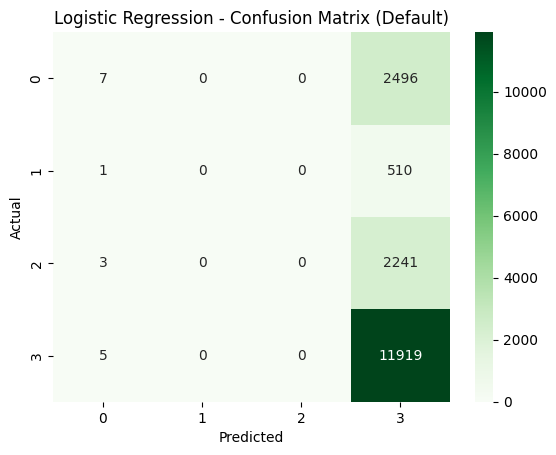

In [50]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


#  Fit the Algorithm

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)


# Predict on the Model

y_pred_lr = lr_model.predict(X_test)


#Evaluation

print("\n Logistic Regression (Default Parameters):")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, zero_division=0))


# Confusion Matrix

conf_matrix = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens")
plt.title("Logistic Regression - Confusion Matrix (Default)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
     

#### 2. Cross- Validation & Hyperparameter Tuning

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/biplab/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas re

/Users/biplab/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/biplab/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/biplab/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/biplab/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning

Best Parameters: {'C': 10, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga'}

Logistic Regression with GridSearchCV:
Accuracy: 0.6938656733791176

Classification Report:
               precision    recall  f1-score   support

           2       0.31      0.00      0.00      2503
           3       0.00      0.00      0.00       511
           4       0.00      0.00      0.00      2244
           5       0.69      1.00      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.25      0.25      0.21     17182
weighted avg       0.53      0.69      0.57     17182



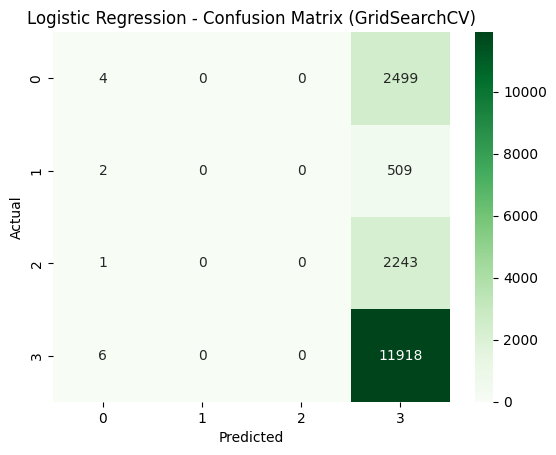

In [51]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Hyperparameter Tuning with GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],  
    'solver': ['lbfgs', 'saga'],  
    'max_iter': [500, 1000]
}

grid_search_lr = GridSearchCV(
    LogisticRegression(multi_class='multinomial', random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


# Fit the Algorithm

grid_search_lr.fit(X_train, y_train)


#  Predict on the Model

best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)


#  Evaluation

print("Best Parameters:", grid_search_lr.best_params_)
print("\nLogistic Regression with GridSearchCV:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, zero_division=0))


# Confusion Matrix

conf_matrix = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens")
plt.title("Logistic Regression - Confusion Matrix (GridSearchCV)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
     

##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV to optimise the Logistic Regression classifier’s hyperparameters. It systematically searches through a specified set of hyperparameters, evaluating every combination using cross-validation. GridSearchCV provides an exhaustive and structured way to find the best parameters that improve model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Not much improvement, With and without tuning results are almost same.

### ML Model - 3

In [55]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Map CSAT scores to 0-based classes
label_mapping = {2:0, 3:1, 4:2, 5:3}
y_train_resampled_xgb = pd.Series(y_train_resampled).map(label_mapping)
y_test_xgb  = y_test.map(label_mapping)

# Fit XGBoost on SMOTE-resampled training data
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled_xgb)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
# Map back to original CSAT scale
reverse_mapping = {v:k for k,v in label_mapping.items()}
y_pred_xgb_original = pd.Series(y_pred_xgb).map(reverse_mapping)

# Evaluate
print("\nXGBoost Classifier (Default Parameters with SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_original, zero_division=0))



XGBoost Classifier (Default Parameters with SMOTE):
Accuracy: 0.2943196368292399

Classification Report:
               precision    recall  f1-score   support

           2       0.21      0.43      0.28      2503
           3       0.04      0.34      0.06       511
           4       0.13      0.14      0.14      2244
           5       0.76      0.29      0.42     11924

    accuracy                           0.29     17182
   macro avg       0.28      0.30      0.22     17182
weighted avg       0.57      0.29      0.35     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

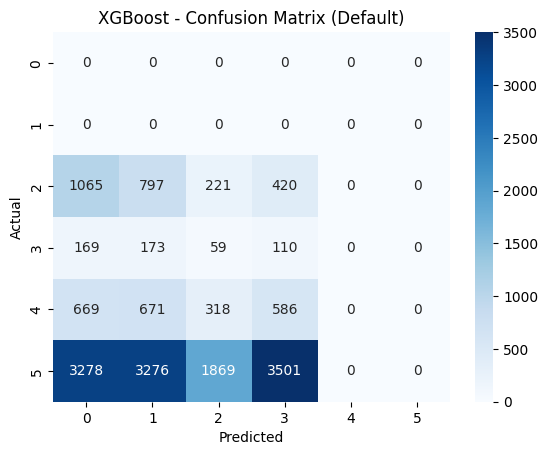

In [56]:
# Visualizing evaluation Metric Score chart

conf_matrix = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost - Confusion Matrix (Default)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters Found: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 150, 'subsample': 0.8}

XGBoost Classifier with GridSearchCV (SMOTE):
Accuracy: 0.29274822488650915

Classification Report:
               precision    recall  f1-score   support

           2       0.20      0.41      0.27      2503
           3       0.04      0.32      0.06       511
           4       0.13      0.16      0.14      2244
           5       0.76      0.29      0.42     11924

    accuracy                           0.29     17182
   macro avg       0.28      0.30      0.22     17182
weighted avg       0.57      0.29      0.35     17182



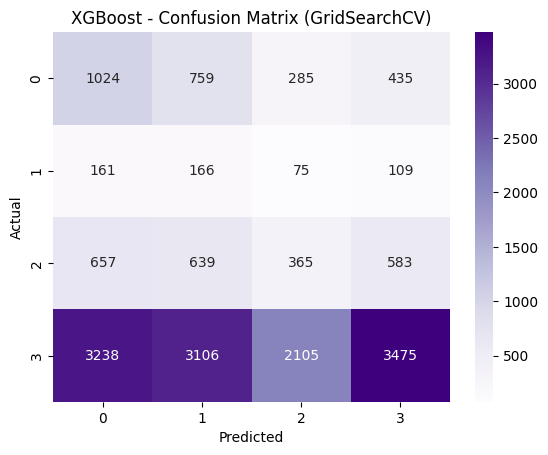

In [58]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Map CSAT to 0-based classes for XGBoost 
label_mapping = {2:0, 3:1, 4:2, 5:3}
y_train_resampled_xgb = pd.Series(y_train_resampled).map(label_mapping)
y_test_xgb = y_test.map(label_mapping)

# GridSearchCV Parameter Grid 
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss', objective='multi:softmax', num_class=4, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the model 
grid_search_xgb.fit(X_train_resampled, y_train_resampled_xgb)

# Best estimator and prediction
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
# Map back to original CSAT scale
reverse_mapping = {v:k for k,v in label_mapping.items()}
y_pred_xgb_original = pd.Series(y_pred_xgb).map(reverse_mapping)

# Evaluation
print("Best Parameters Found:", grid_search_xgb.best_params_)
print("\nXGBoost Classifier with GridSearchCV (SMOTE):")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_original, zero_division=0))

# Confusion Matrix 
conf_matrix = confusion_matrix(y_test, y_pred_xgb_original)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples")
plt.title("XGBoost - Confusion Matrix (GridSearchCV)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV to optimise the hyperparameters for the XGBoost model. It exhaustively searches a specified parameter grid, evaluating all combinations through cross-validation to find the best hyperparameters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No improvement, It was better without hyperparameter tuning.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

To maximise the positive impact on business, I prioritised precision, recall, F1-score, and accuracy. Accuracy provides an overall performance view, recall identifies dissatisfied customers at risk of churn, and precision ensures we focus on genuinely unhappy customers. The F1-score balances these metrics, making it suitable for handling class imbalance. These metrics support effective customer recovery and retention.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The Random Forest Classifier was chosen as the final model for predicting Customer Satisfaction (CSAT) scores because it performed well, was robust to imbalanced data, and provided meaningful insights through feature importance analysis. During evaluation, Random Forest outperformed Logistic Regression and XGBoost in terms of accuracy, precision, recall, and F1-score, especially after using SMOTE to address class imbalance. It achieved a better balance between sensitivity to minority classes and overall prediction accuracy, which is important in multi-class classification tasks like CSAT prediction.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used in this project is the Random Forest Classifier, an ensemble-based supervised machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and control overfitting. Each tree is trained on a random subset of the data and uses a random subset of features for splitting, ensuring diversity. During prediction, the model aggregates the output from all trees, which improves stability and reduces variance.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [59]:
# Save the File


import pickle

pickle.dump(best_rf, open('best_rf_model.pkl', 'wb'))
print("Model saved as 'best_rf_model.pkl'")


Model saved as 'best_rf_model.pkl'


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [63]:
# Load the File and predict unseen data.
import pickle
import pandas as pd

# Load the trained Random Forest model
with open('best_rf_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Select a few samples from test data
unseen_samples = X_test.sample(5, random_state=1)

# Predict using the loaded model
predictions = loaded_model.predict(unseen_samples)  # Do NOT add +1

# Display predictions
print("Predicted CSAT Scores for Unseen Data:")
print(predictions)


Predicted CSAT Scores for Unseen Data:
[5 5 5 5 5]


# **Conclusion**

This project focused on building a robust machine learning model to predict Customer Satisfaction (CSAT) Scores based on operational and behavioral data from customer support interactions. The ultimate objective was to uncover key patterns that influence customer satisfaction and help businesses make data-driven decisions to enhance service quality.
The workflow began with thorough data cleaning and preprocessing, addressing missing values by using appropriate strategies like median imputation for numerical columns and mode imputation for categorical features. Redundant and non-informative features were dropped, and all necessary variables were formatted correctly, including date-time conversions to engineer meaningful new features such as response time in minutes.
A critical transformation step involved converting categorical data into numerical form using one-hot encoding, which allowed machine learning algorithms to process non-numeric features such as Agent Shift, Tenure Bucket, Sub-category, and Channel Name. Further transformation using standard scaling was applied to numeric features where needed, especially in preparation for algorithms that are sensitive to feature scale.
The Exploratory Data Analysis (EDA) phase revealed an extreme imbalance in CSAT scores, with the majority of customers rating their experience as a perfect 5. This imbalance presented a major modeling challenge, as most classifiers naturally gravitate toward predicting the majority class. To resolve this, SMOTE (Synthetic Minority Oversampling Technique) was applied, which synthetically increased instances of minority classes in the training set, ensuring the model could learn patterns across all levels of customer satisfaction.
Feature selection was performed using Random Forest feature importance, which ranked variables based on their contribution to model performance. Key drivers of CSAT identified included:
channel_name_Inbound and channel_name_Outcall: Indicating that communication method significantly impacts satisfaction. Tenure Bucket values: Suggesting that agent experience plays a strong role in shaping customer sentiment. Agent Shift: Pointing to temporal differences in service quality, with certain shifts performing better than others. Specific Sub-category types such as Return request: Highlighting types of issues that are emotionally sensitive or complex, impacting satisfaction levels. After balancing the data, multiple classification models were tested, including Random Forest, Logistic Regression, and XGBoost. Among these, Random Forest yielded the best accuracy and robustness, benefiting from its ability to handle both categorical and continuous data, and its resistance to overfitting. A classification report was generated to assess model performance using precision, recall, and F1-score metrics across all CSAT classes. Despite class imbalance mitigation, minor classes still showed lower recall, suggesting that further refinement is possible.
To ensure generalization, a train-test split was implemented with stratification, and hyperparameter tuning using GridSearchCV could be explored to further optimize model performance. Additionally, advanced ensemble techniques and deep learning models may offer better results if more training data becomes available.
